# XAI for LVC Dataset: SHAP and LIME

This notebook explains model behavior for the LVC project using:

- SHAP (global feature importance)
- LIME (local explanation)

Strategy:
- Use the best synthetic-data scenario for data generation: CTGAN 30x
- Use a tree-based model for SHAP interpretability: Random Forest
- Evaluate explanations on the real holdout set


In [13]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import shap
from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt

In [14]:
DATA_PATH = "../data/raw/leish_dataset.csv"
SYNTH_DIR = "../data/synthetic"
TARGET = "diagnosis"

BEST_GENERATOR = "CTGAN"
BEST_SCENARIO = "30x"
BEST_SEED = 41

TEST_SIZE = 0.30
MIN_BREED_COUNT = 10

In [15]:
df = pd.read_csv(DATA_PATH)

# Group rare breeds into 'other'
breed_counts = df["breed_name"].value_counts(dropna=False)
rare_breeds = breed_counts[breed_counts < MIN_BREED_COUNT].index
df["breed_name"] = df["breed_name"].replace(rare_breeds, "other")

print("Real dataset shape:", df.shape)
display(df.head())

Real dataset shape: (456, 17)


,diagnosis,general_state,ectoparasites,nutritional_state,coat,nails,mucosa_color,muzzle_ear_lesion,lymph_nodes,blepharitis,conjunctivitis,alopecia,bleeding,skin_lesion,muzzle_lip_depigmentation,animal_sex,breed_name
0,negativo,bom,ausente,adequado,normal,normal,normal,presente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,SRD
1,negativo,bom,ausente,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,M,SRD
2,negativo,bom,leve,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,Poodle
3,negativo,bom,ausente,adequado,normal,leves_moderadas,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,F,other
4,negativo,bom,leve,leve_moderado,normal,leves_moderadas,normal,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Ausente,ausente,F,SRD


In [16]:
label_encoder = LabelEncoder()
label_encoder.fit(df[TARGET])

print("Classes:", list(label_encoder.classes_))

Classes: ['negativo', 'positivo']


In [17]:
train_real_df, test_real_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df[TARGET],
    random_state=BEST_SEED
)

X_test_real = test_real_df.drop(columns=[TARGET]).copy()
y_test_real = label_encoder.transform(test_real_df[TARGET])

print("Test real shape:", X_test_real.shape)
print(pd.Series(y_test_real).value_counts())

Test real shape: (137, 16)
0    96
1    41
Name: count, dtype: int64


In [18]:
file_name = f"{BEST_GENERATOR.lower()}_{BEST_SCENARIO}_seed{BEST_SEED}.csv"
file_path = os.path.join(SYNTH_DIR, file_name)

synth_df = pd.read_csv(file_path)
synth_df["breed_name"] = synth_df["breed_name"].replace(rare_breeds, "other")

X_synth = synth_df.drop(columns=[TARGET]).copy()
y_synth = label_encoder.transform(synth_df[TARGET])

print("Synthetic dataset shape:", synth_df.shape)
display(synth_df.head())

Synthetic dataset shape: (9570, 17)


,diagnosis,general_state,ectoparasites,nutritional_state,coat,nails,mucosa_color,muzzle_ear_lesion,lymph_nodes,blepharitis,conjunctivitis,alopecia,bleeding,skin_lesion,muzzle_lip_depigmentation,animal_sex,breed_name
0,positivo,regular,leve,adequado,normal,normal,levemente_hipercorada,presente,leves_moderadas,presente,Conjuntivite Leve,presente,ausente,Leve/Moderada,presente,F,SRD
1,positivo,bom,grave,grave,normal,leves_moderadas,normal,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Ausente,ausente,F,SRD
2,positivo,regular,leve,adequado,leves_moderadas,leves_moderadas,levemente_hipercorada,presente,leves_moderadas,ausente,Conjuntivite Leve,ausente,ausente,Ausente,presente,M,SRD
3,positivo,bom,ausente,leve_moderado,leves_moderadas,leves_moderadas,normal,presente,leves_moderadas,ausente,Conjuntivite Leve,ausente,ausente,Ausente,presente,F,SRD
4,positivo,regular,ausente,leve_moderado,normal,leves_moderadas,normal,presente,leves_moderadas,ausente,Conjuntivite Leve,ausente,ausente,Ausente,presente,M,SRD


In [19]:
categorical_features = X_synth.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X_synth.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['general_state', 'ectoparasites', 'nutritional_state', 'coat', 'nails', 'mucosa_color', 'muzzle_ear_lesion', 'lymph_nodes', 'blepharitis', 'conjunctivitis', 'alopecia', 'bleeding', 'skin_lesion', 'muzzle_lip_depigmentation', 'animal_sex', 'breed_name']
Numerical features: []


In [20]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", rf_model)
])

pipe_rf.fit(X_synth, y_synth)

y_pred = pipe_rf.predict(X_test_real)

print("Accuracy:", accuracy_score(y_test_real, y_pred))
print("Precision:", precision_score(y_test_real, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_real, y_pred, zero_division=0))
print("F1:", f1_score(y_test_real, y_pred, zero_division=0))

Accuracy: 0.5255474452554745
Precision: 0.3235294117647059
Recall: 0.5365853658536586
F1: 0.4036697247706422


In [22]:
X_train_transformed = pipe_rf.named_steps["preprocessor"].transform(X_synth)
X_test_transformed = pipe_rf.named_steps["preprocessor"].transform(X_test_real)

feature_names = pipe_rf.named_steps["preprocessor"].get_feature_names_out()

print("Train transformed shape:", X_train_transformed.shape)
print("Test transformed shape:", X_test_transformed.shape)
print("Number of features:", len(feature_names))
print(feature_names[:20])

Train transformed shape: (9570, 40)
Test transformed shape: (137, 40)
Number of features: 40
['cat__general_state_bom' 'cat__general_state_regular'
 'cat__ectoparasites_ausente' 'cat__ectoparasites_grave'
 'cat__ectoparasites_leve' 'cat__nutritional_state_adequado'
 'cat__nutritional_state_grave' 'cat__nutritional_state_leve_moderado'
 'cat__coat_graves' 'cat__coat_leves_moderadas' 'cat__coat_normal'
 'cat__nails_leves_moderadas' 'cat__nails_normal'
 'cat__mucosa_color_congesta' 'cat__mucosa_color_levemente_hipercorada'
 'cat__mucosa_color_normal' 'cat__muzzle_ear_lesion_ausente'
 'cat__muzzle_ear_lesion_presente' 'cat__lymph_nodes_leves_moderadas'
 'cat__lymph_nodes_normal']


In [23]:
explainer = shap.TreeExplainer(pipe_rf.named_steps["clf"])
shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [24]:
# Handle SHAP output format safely

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    expected_value_pos = explainer.expected_value[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
    expected_value_pos = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_values_pos = shap_values
    expected_value_pos = explainer.expected_value

print("SHAP positive-class matrix shape:", np.array(shap_values_pos).shape)

SHAP positive-class matrix shape: (137, 40)


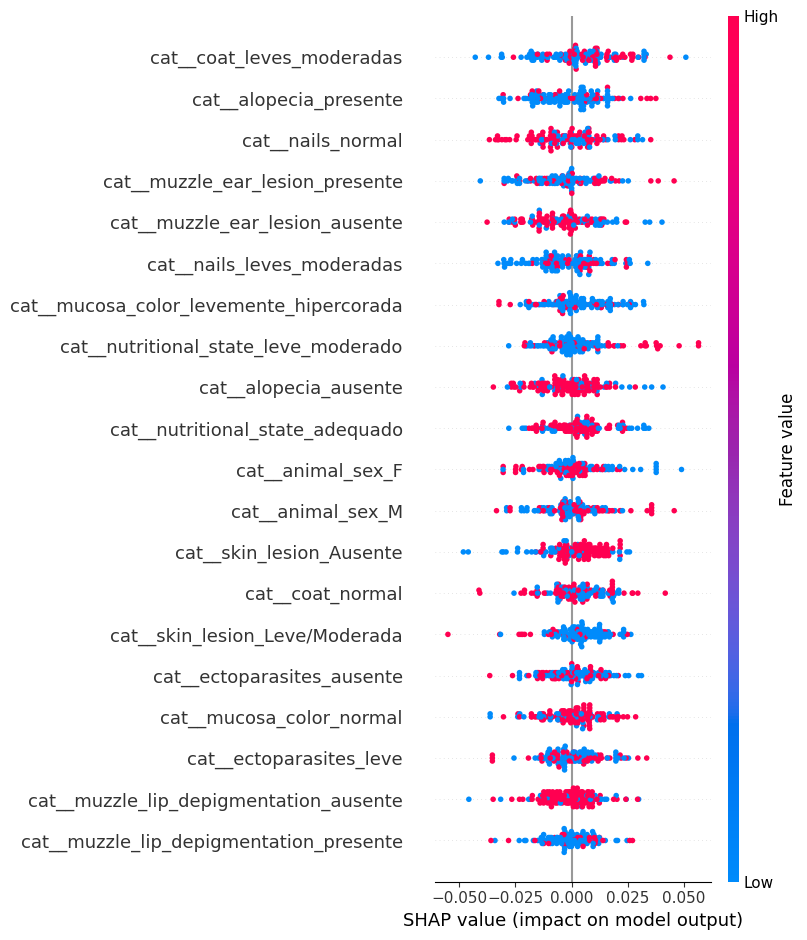

In [25]:
shap.summary_plot(
    shap_values_pos,
    X_test_transformed,
    feature_names=feature_names
)

In [26]:
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

display(shap_importance_df.head(20))

,feature,mean_abs_shap
9,cat__coat_leves_moderadas,0.013163
26,cat__alopecia_presente,0.011499
12,cat__nails_normal,0.011302
17,cat__muzzle_ear_lesion_presente,0.010985
16,cat__muzzle_ear_lesion_ausente,0.010818
11,cat__nails_leves_moderadas,0.010526
14,cat__mucosa_color_levemente_hipercorada,0.010439
7,cat__nutritional_state_leve_moderado,0.010266
25,cat__alopecia_ausente,0.010222
5,cat__nutritional_state_adequado,0.010153


In [27]:
shap_importance_df.to_csv("../results/tables/shap_feature_importance.csv", index=False)

print("Saved SHAP feature importance to ../results/tables/shap_feature_importance.csv")

Saved SHAP feature importance to ../results/tables/shap_feature_importance.csv


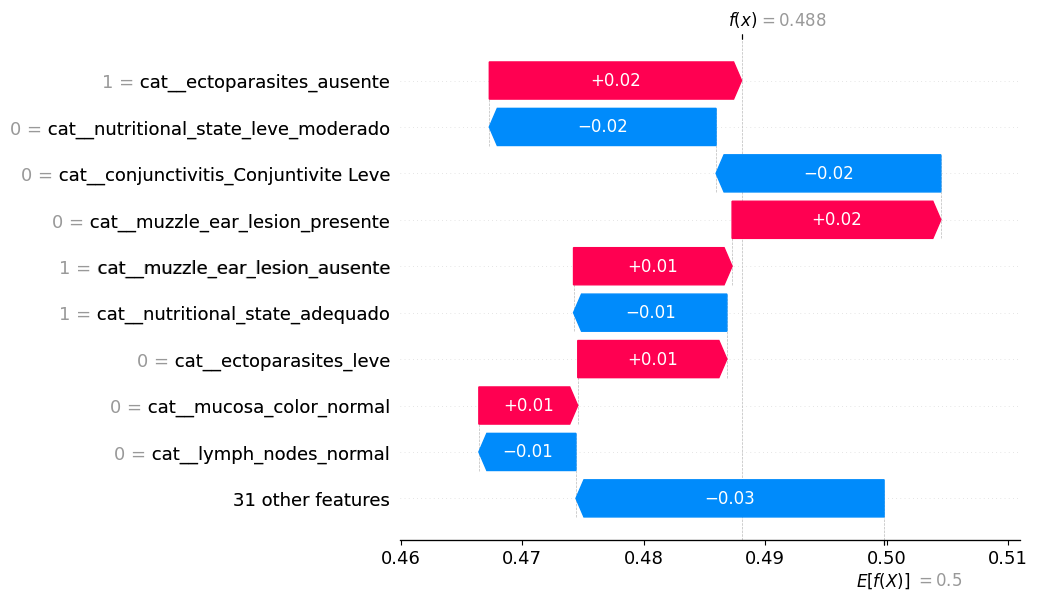

In [28]:
instance_idx = 0

waterfall_exp = shap.Explanation(
    values=shap_values_pos[instance_idx],
    base_values=expected_value_pos,
    data=X_test_transformed[instance_idx],
    feature_names=feature_names
)

shap.plots.waterfall(waterfall_exp)

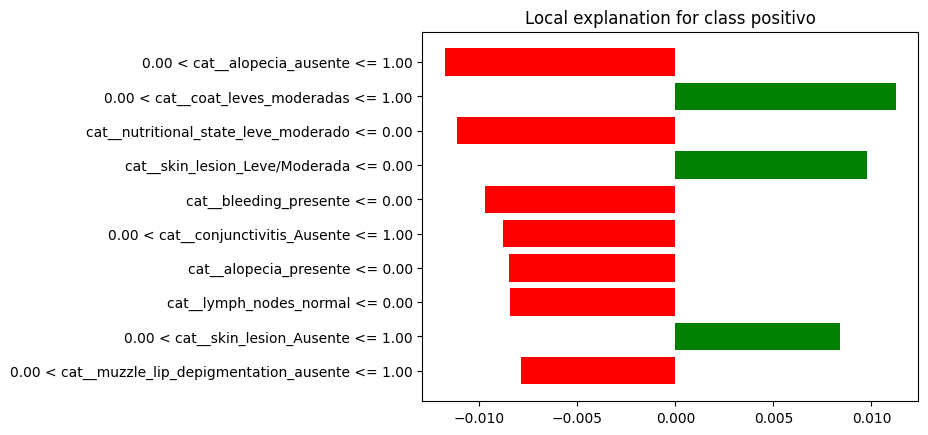

LIME explanation saved at: ../results/images/lime_explanation.png


In [30]:
import os
import matplotlib.pyplot as plt

# Garantir diretório de saída
os.makedirs("../results/images", exist_ok=True)

# Criar explainer LIME
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed),
    feature_names=list(feature_names),
    class_names=list(label_encoder.classes_),
    mode="classification"
)

# Escolher instância
instance_idx = 0

# Gerar explicação
lime_exp = lime_explainer.explain_instance(
    data_row=np.array(X_test_transformed[instance_idx]),
    predict_fn=pipe_rf.named_steps["clf"].predict_proba,
    num_features=10
)

# ---------------------------
# GERAR FIGURA (COMPATÍVEL COM GITHUB)
# ---------------------------
fig = lime_exp.as_pyplot_figure()

# Salvar imagem
output_path = "../results/images/lime_explanation.png"
fig.savefig(output_path, bbox_inches="tight")

plt.show()

print(f"LIME explanation saved at: {output_path}")

## Notes

- SHAP is used for global and local explanations with a tree-based model.
- LIME is used for local explanation of a single instance.
- The model is trained on the best synthetic-data scenario (CTGAN 30x) and interpreted on the real holdout set.
- Random Forest is used here for interpretability, even though KNN achieved the best screening recall.
